# Project 2 - Financial Time Series
Group 7
- Juan José Rincón
- Marco de Palma
- Alberto Megino
- Cecile Tambey
- Issam El Hoss

#### Install and import requered packages

In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 8.3 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import skew, kurtosis, normaltest, norm
from arch import arch_model

from statsmodels.tsa.arima.model import ARIMA


# Brent crude Oil prices data

# Understanding our data

Brent crude oil is one of the world's primary benchmarks for pricing international oil transactions. It reflects production from fields in the North Sea and is widely regarded as an indicator of global supply-demand dynamics, geopolitical risk, and macroeconomic conditions.

In our analysis we will look at crude oil prices from 2017 until 2025.
Between 2017 and 2025, Brent prices experienced significant volatility: a gradual recovery from the 2014-2016 downturn, sharp disruptions during the 2020 COVID-19 demand collapse, a rapid rebound during the subsequent economic reopening, and renewed upward pressure following geopolitical shocks such as the Russia-Ukraine conflict.

The GARCH model is a standard framework for analyzing and forecasting time-varying volatility in financial and commodity markets.

In [3]:
# Fetch brent data from Yahoo Finance (2019-2024)
brent = yf.download("BZ=F", start="2017-01-01", end="2025-12-01", progress=False)
brent.columns = [c[0] for c in brent.columns ]
brent

/tmp/ipython-input-2280462263.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  brent = yf.download("BZ=F", start="2017-01-01", end="2025-12-01", progress=False)


,Close,High,Low,Open,Volume
Date,,,,,
2017-01-03,55.470001,58.369999,55.290001,57.049999,42688
2017-01-04,56.459999,56.529999,55.340000,55.689999,27804
2017-01-05,56.889999,57.340000,56.009998,56.540001,32833
2017-01-06,57.099998,57.459999,56.299999,56.880001,24948
2017-01-09,54.939999,56.990002,54.740002,56.860001,25860
...,...,...,...,...,...
2025-11-21,62.560001,63.139999,61.869999,63.130001,43029
2025-11-24,63.369999,63.529999,61.930000,62.560001,30888
2025-11-25,62.480000,63.410000,61.610001,63.410000,26580


In [4]:
brent.describe()

,Close,High,Low,Open,Volume
count,2243.000000,2243.000000,2243.000000,2243.000000,2243.000000
mean,70.481792,71.527062,69.386572,70.469148,31830.123495
std,16.933071,17.225538,16.603743,16.907677,14027.540865
min,19.330000,21.270000,16.000000,19.559999,0.000000
25%,61.129999,61.934999,60.145000,61.025000,23580.500000
50%,70.760002,71.790001,69.839996,70.830002,30674.000000
75%,80.744999,81.864998,79.410000,80.719997,38179.500000
max,127.980003,137.000000,122.500000,129.570007,175031.000000


In [5]:
# Compute percentage log-returns
brent['Log_Return'] = np.log(brent['Close'] / brent['Close'].shift(1)) * 100
brent = brent.dropna().copy()

# Compute absolute log-returns
brent['Abs_Log_Return'] = np.abs(brent['Log_Return'])

# Compute rolling 60-day standard deviation
brent['Rolling_Std'] = brent['Log_Return'].rolling(window=60).std()


The dataset contains 2,243 daily observations of Brent crude oil prices from 2017 to 2025. Across this period, the average Close price is approximately 70.4 usd per barrell , with a standard deviation of 16.93 usd, indicating a market characterized by substantial short-run variability. The range is wide: the minimum close price of 19.33 usd reflects the extreme downward pressure during the 2020 COVID-19 demand collapse, whereas the maximum close price of 127.98 usd aligns with the sharp post-pandemic recovery and the pricing shock following the onset of the Russia–Ukraine conflict in early 2022.

The Open, High, and Low series exhibit similar dispersion, with means clustered around usd 70–72 but with upper extremes exceeding usd 120 and lower extremes falling near usd 20. The relatively tight interquartile ranges (e.g., 25% = ~61.13, 75% = ~80.74 for the Close series) show that most trading occurred within a moderate band, while the extremes contributed disproportionately to total volatility. This is consistent with commodity price behavior where infrequent but large shocks drive volatility clustering.

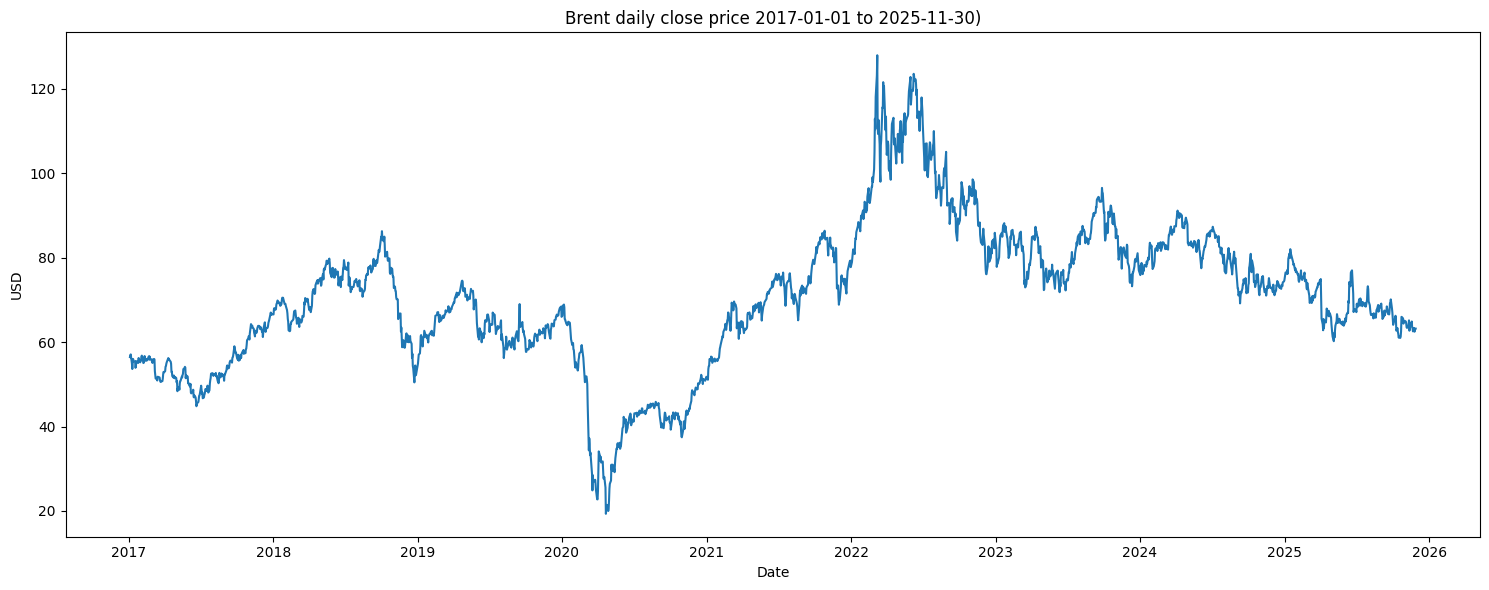

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(brent.index, brent['Close'], linestyle='-')
plt.title("Brent daily close price 2017-01-01 to 2025-11-30)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

Overall, the distributional characteristics of the dataset—large variance, pronounced tails, and clear evidence of volatility clustering—support the application of GARCH-type models. The wide dispersion between minimum and maximum prices underscores the presence of structural breaks and persistent volatility shifts, phenomena that simple constant-variance models cannot capture. A GARCH framework allows the conditional variance to evolve dynamically and respond to both recent shocks and longer-term volatility persistence, making it well-suited for modelling Brent oil price behavior during this turbulent period.

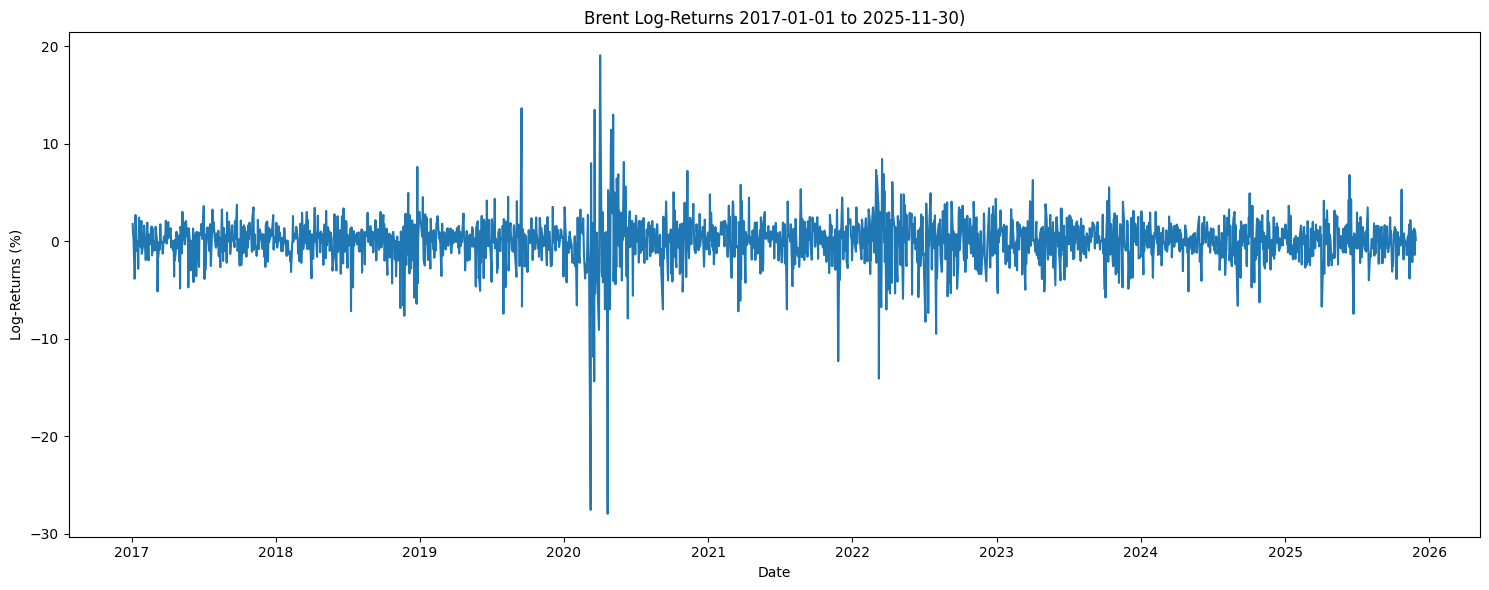

In [7]:
plt.figure(figsize=(15, 6))
plt.plot(brent.index, brent['Log_Return'], linestyle='-')
plt.title("Brent Log-Returns 2017-01-01 to 2025-11-30)")
plt.xlabel("Date")
plt.ylabel("Log-Returns (%)")
plt.tight_layout()
plt.show()


The log-return series for Brent crude oil displays several features typical of financial and commodity markets that motivate the use of GARCH models. Returns fluctuate around zero, but the variance is clearly time-varying. Periods of calm are followed by bursts of large movements, indicating volatility clustering—a core characteristic that GARCH is designed to capture.

The most extreme volatility occurs in early 2020, where returns exhibit exceptionally sharp negative and positive spikes related to the COVID-19 shock and the collapse in global oil demand. Additional volatility episodes appear around 2019 and 2022 during periods of geopolitical uncertainty. These large, irregular shocks and the presence of fat tails reinforce the inadequacy of constant-variance models.

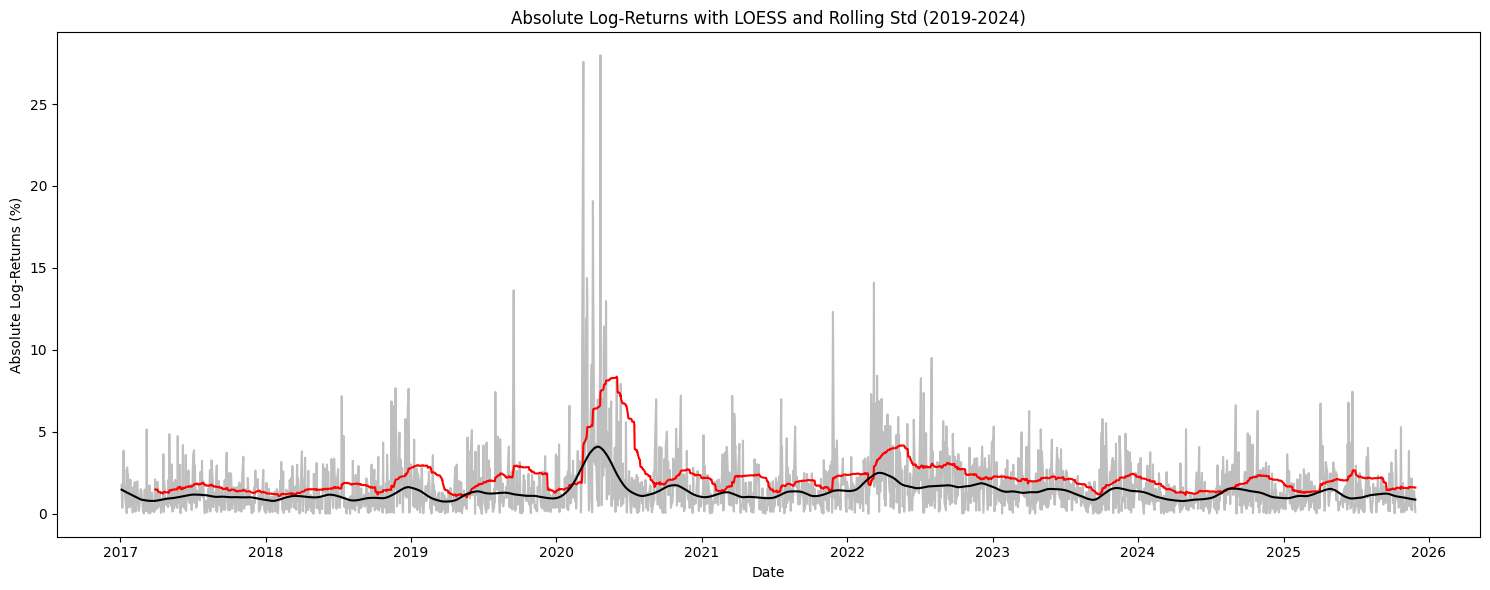

In [8]:
# LOESS smoothing (LOWESS from statsmodels)
lowess = sm.nonparametric.lowess
smoothed_abs = lowess(brent['Abs_Log_Return'], brent.index, frac=0.03)  # frac=0.03 controls smoothness



plt.figure(figsize=(15, 6))
plt.plot(brent.index, brent['Abs_Log_Return'], color='gray', alpha=0.5, label='Absolute Log-Returns')
plt.plot(brent.index, brent['Rolling_Std'], color='red', label='60-Day Rolling Std')
plt.plot(brent.index, smoothed_abs[:, 1], color='black', label='LOESS Smoothed Abs Returns')
plt.title("Absolute Log-Returns with LOESS and Rolling Std (2019-2024)")
plt.xlabel("Date")
plt.ylabel("Absolute Log-Returns (%)")
plt.tight_layout()
plt.show()


The absolute log-return, overlaid with LOESS and a rolling standard deviation, provides clear evidence of time-varying volatility in Brent crude oil prices. While most daily movements remain small, the smoothed measures highlight recurring periods of elevated volatility. The most pronounced spike occurs in early 2020, reflecting the exceptional uncertainty and price dislocation during the onset of the COVID-19 crisis. Both the LOESS curve (red) and the rolling volatility (black) rise sharply during this episode, confirming a sustained shift rather than an isolated shock.

Overall, volatility clusters are clear, with the first starting towards end of 2018, and many more being evident every year until 2025.

# Plot the ACF/PCF of the log returns
This helps us know if the data has any mean autocorrelation

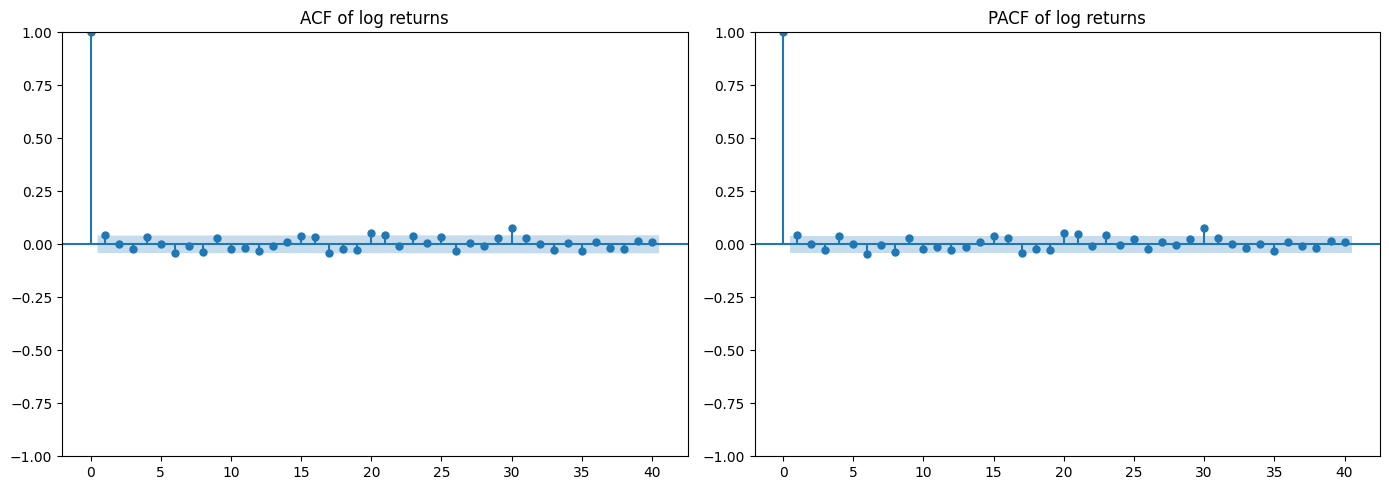

In [9]:
# Create ACF and PACF plots for the series with both differences
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# ACF Plot
sm.graphics.tsa.plot_acf(brent['Log_Return'], lags=40, ax=axs[0])
axs[0].set_title("ACF of log returns")

# PACF Plot
sm.graphics.tsa.plot_pacf(brent['Log_Return'], lags=40, ax=axs[1], method='ywm')
axs[1].set_title("PACF of log returns")

plt.tight_layout()
plt.show()

From the ACF and PACF we could see that the model has no autocorrelation in the mean value, since all the lags of the log returns are statistically zero.

# FITTING A NORMAL DISTRIBUTION
Check if the log returns follows a Normal distribution.
We compute the sample mean, variance, skewness and kurtosis.
Plot the histogram of the data with the best Normal line and report the p-value of a test of Normality.

Mean: 0.0058
Variance: 5.9164
Skewness: -1.3438
Kurtosis: 20.2620
Normality Test p-value: 0.0000 (Not Normal)


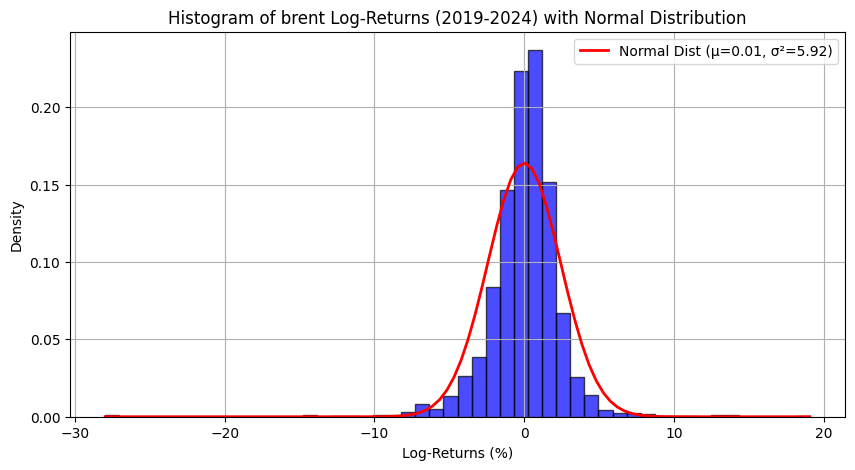

In [ ]:

# Compute statistics
mean_return = np.mean(brent['Log_Return'])
variance_return = np.var(brent['Log_Return'])
skewness_return = skew(brent['Log_Return'])
kurtosis_return = kurtosis(brent['Log_Return'])

# Normality test (D'Agostino and Pearson’s test)
stats_test, p_value = normaltest(brent['Log_Return'])
normality_result = "Normal" if p_value > 0.05 else "Not Normal"

# Print statistics
print(f"Mean: {mean_return:.4f}")
print(f"Variance: {variance_return:.4f}")
print(f"Skewness: {skewness_return:.4f}")
print(f"Kurtosis: {kurtosis_return:.4f}")
print(f"Normality Test p-value: {p_value:.4f} ({normality_result})")

# Plot histogram with overlaid normal distribution
plt.figure(figsize=(10, 5))
count, bins, _ = plt.hist(brent['Log_Return'], bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)

# Compute normal distribution curve
x = np.linspace(bins[0], bins[-1], 100)
pdf = norm.pdf(x, mean_return, np.sqrt(variance_return))
plt.plot(x, pdf, color='red', lw=2, label=f'Normal Dist (μ={mean_return:.2f}, σ²={variance_return:.2f})')

plt.xlabel("Log-Returns (%)")
plt.ylabel("Density")
plt.title("Histogram of brent Log-Returns (2019-2024) with Normal Distribution")
plt.legend()
plt.grid()
plt.show()

Although the mean return is close to zero (0.0058), the distribution exhibits strong negative skewness (–1.3438), indicating that large negative returns occur more frequently than large positive ones. This asymmetry is typical in energy markets, where downside shocks (such as demand collapses or supply surges) tend to be sharper and more abrupt.

The kurtosis value of 20.26 is far above the normal benchmark of 3, confirming heavy tails and a tendency for extreme observations. These tail features are visible in the histogram, where several large outliers fall well outside the range implied by the fitted normal curve. The normality test further reinforces this conclusion, with a p-value of 0.0000 clearly rejecting the null hypothesis of normality.

# FITTING A T-DISTRIBUTION
Check if the data follows a T-distribution. This allows us to set the distribution parameter of the GARCH models.

Fitted t-distribution parameters:
Degrees of Freedom: 3.0752
Location: 0.1481
Scale: 1.4632
Variance: 6.1232
Kurtosis: Infinite


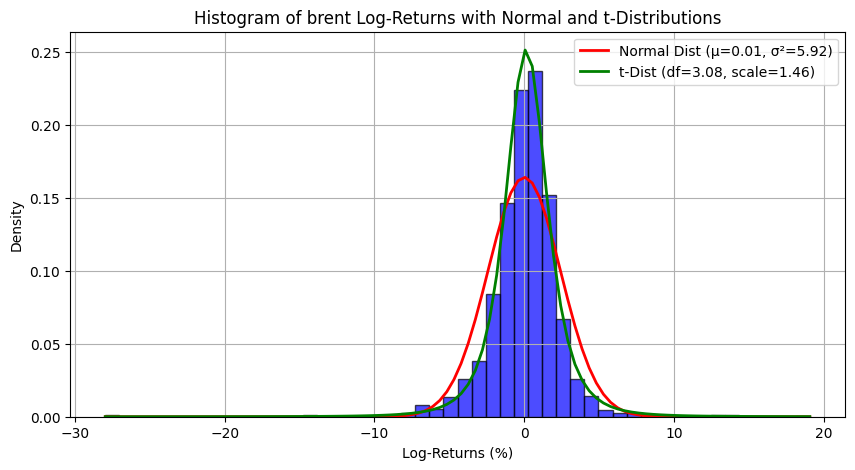

In [ ]:
from scipy.stats import t

# Fit a t-distribution to the log-returns
params = t.fit(brent['Log_Return'])  # Direct fitting

# Extract fitted parameters
df_t, loc_t, scale_t = params

# Compute variance and kurtosis of the fitted t-distribution
variance_t = (df_t / (df_t - 2)) * (scale_t ** 2) if df_t > 2 else np.nan
kurtosis_t = (6 / (df_t - 4)) if df_t > 4 else np.inf  # Infinite for df <= 4

# Print fitted parameters and statistics
print(f"Fitted t-distribution parameters:")
print(f"Degrees of Freedom: {df_t:.4f}")
print(f"Location: {loc_t:.4f}")
print(f"Scale: {scale_t:.4f}")
print(f"Variance: {variance_t:.4f}")
print(f"Kurtosis: {'Infinite' if np.isinf(kurtosis_t) else f'{kurtosis_t:.4f}'}")

# Plot histogram with normal and t-distribution curves
plt.figure(figsize=(10, 5))
count, bins, _ = plt.hist(brent['Log_Return'], bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)

# Compute normal and t-distribution curves
x = np.linspace(bins[0], bins[-1], 100)
pdf_norm = norm.pdf(x, np.mean(brent['Log_Return']), np.std(brent['Log_Return']))
pdf_t = t.pdf(x, df_t, loc=loc_t, scale=scale_t)

plt.plot(x, pdf_norm, color='red', lw=2, label=f'Normal Dist (μ={np.mean(brent["Log_Return"]):.2f}, σ²={np.var(brent["Log_Return"]):.2f})')
plt.plot(x, pdf_t, color='green', lw=2, label=f't-Dist (df={df_t:.2f}, scale={scale_t:.2f})')

plt.xlabel("Log-Returns (%)")
plt.ylabel("Density")
plt.title("Histogram of brent Log-Returns with Normal and t-Distributions")
plt.legend()
plt.grid()
plt.show()


Overall, the t-distribution provides a substantially better empirical representation of the return distribution than the normal distribution. This finding supports the use of GARCH models with Student’s t innovations, which are specifically designed to accommodate heavy tails and produce more realistic volatility estimates and risk measures.

# Model Selection
We try a bunch of combinations fo 3 main models: 1) GARCH model as a benchmark, 2) GJR-GARCH that captures asymmetric volatility, 3) EGARCH that captures asymmetric volatility with log variance capturing heavy tails and large spikes.  
All of the models where fitted with a student-t distribution, but we also tried different forms of mean modeling, from AR(0), AR(1) to constant or zero mean.  

To select the best model in terms of model fit, we choose to compare the models by the AIC. We choose it over the BIC since the model fit between models is not that big, and the BIC will end up only choosing the simplest model given its model complexity penalization. Obviously the simplest models would be the GARCH ones but, in this case with asymmetric volatility we would like to select a model that incorporates this instead of the benchmark model.
Also I suggest you try different models.

In [ ]:
returns = brent['Log_Return'].dropna()

In [ ]:
param_grid = [
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1, 'mean':'AR','ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2, 'mean':'AR','ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1, 'mean':'AR','ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'AR','ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'AR','ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':0},

    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1, 'mean':'AR','ar_lags':1},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2, 'mean':'AR','ar_lags':1},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1, 'mean':'AR','ar_lags':1},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':1},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'AR','ar_lags':1},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':1},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':1},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'AR','ar_lags':1},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'AR','ar_lags':1},

    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1, 'mean':'Constant', 'ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2, 'mean':'Constant', 'ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1, 'mean':'Constant', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'Constant', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'Constant', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'Constant', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'Constant', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'Constant', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'Constant', 'ar_lags':0},

    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'Zero', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},

    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 1, 'o': 0, 'q': 2, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GARCH', 'vol': 'GARCH', 'p': 2, 'o': 0, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'Zero', 'ar_lags':0},
    {'name': 'GJR-GARCH', 'vol': 'GARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 2, 'mean':'Zero', 'ar_lags':0},
    {'name': 'EGARCH', 'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 1, 'mean':'Zero', 'ar_lags':0},
]

len(param_grid)

45

In [ ]:
cv = []
for i in range(len(param_grid)):
  params = param_grid[i]
  garch_model = arch_model(returns, mean = params['mean'], lags=params['ar_lags'], vol=params['vol'], p=params['p'], o=params['o'], q=params['q'], dist='t')
  garch_fit = garch_model.fit(disp='off')
  aic = garch_fit.aic
  params['aic']=aic
  print(i,aic)
  cv.append(params)

0 9350.930815251295
1 9352.930815234935
2 9352.636406675043
3 9347.847383977829
4 9349.847383485932
5 9349.812477724548
6 9349.415691199916
7 9351.415690264534
8 9351.112158672207
9 9348.8477237387
10 9350.847724036423
11 9350.547481954523
12 9345.698971113565
13 9347.698970693073
14 9347.662489654447
15 9347.256992757033
16 9349.25699284515
17 9348.941375172568
18 9350.930815251295
19 9352.930815234935
20 9352.636406675043
21 9347.847383977829
22 9349.847383485932
23 9349.812477724548
24 9349.415691199916
25 9351.415690264534
26 9351.112158672207
27 9363.56796622804
28 9365.567966252165
29 9365.26019141296
30 9357.527877782068
31 9359.527877725128
32 9359.508146710925
33 9358.190224841355
34 9360.190224829064
35 9359.872585467907
36 9363.56796622804
37 9365.567966252165
38 9365.26019141296
39 9357.527877782068
40 9359.527877725128
41 9359.508146710925
42 9358.190224841355
43 9360.190224829064
44 9359.872585467907


In [ ]:
cv_df = pd.DataFrame(cv)
best_params = cv_df.loc[cv_df['aic'].idxmin()]
best_params

,12
name,GJR-GARCH
vol,GARCH
p,1
o,1
q,1
mean,AR
ar_lags,1
aic,9345.698971


The best-fitting model according to AIC is an GJR-GARCH(1,1,1) with an AR(1) mean. This tells us two things:

1. Mean dynamics:
The AR(1) mean term indicates that today’s return is slightly related to yesterday’s return. This improves the model fit compared with assuming a constant or zero mean.

2. Volatility dynamics:
The GJR-GARCH structure captures key features of oil-market volatility:

    - It allows asymmetric effects, meaning negative shocks increase volatility more than positive shocks (the leverage effect).

    - The q = 1 term shows that volatility is persistent: once volatility becomes high, it tends to stay high for some time.


Overall, the model was chosen because it provides the best balance between statistical fit and complexity, making it the most appropriate volatility model among those tested.

In [ ]:
garch_model = arch_model(returns, mean = best_params['mean'], lags=int(best_params['ar_lags']), vol=best_params['vol'], p=int(best_params['p']), o=int(best_params['o']), q=int(best_params['q']), dist='t')
garch_fit = garch_model.fit(disp='off')
print("\nModel Summary:")
print(garch_fit.summary())


Model Summary:
                            AR - GJR-GARCH Model Results                            
Dep. Variable:                   Log_Return   R-squared:                      -0.003
Mean Model:                              AR   Adj. R-squared:                 -0.003
Vol Model:                        GJR-GARCH   Log-Likelihood:               -4665.85
Distribution:      Standardized Student's t   AIC:                           9345.70
Method:                  Maximum Likelihood   BIC:                           9385.70
                                              No. Observations:                 2241
Date:                      Tue, Dec 16 2025   Df Residuals:                     2239
Time:                              13:17:41   Df Model:                            2
                                    Mean Model                                   
                     coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------

**Interpretation of the GJR-GARCH(1,1,1) Model Results**

**Mean Equation (AR(1))**

- The constant term is positive and statistically significant, indicating returns have a small positive unconditional mean.

- The AR(1) coefficient is not significant (p = 0.887), meaning yesterday’s return does not meaningfully predict today’s return. The mean dynamics are therefore weak, which is typical for daily financial returns.

**Volatility Equation (GJR-GARCH)**
The volatility parameters are highly informative:

- omega (0.1439, p < 0.00): is the baseline variance level; significant.

- alpha (0.0.0503, p < 0.00): Measures the impact of the magnitude of shocks (squared returns at lag 1). A positive and significant value means larger shocks increase volatility.

- gamma (0.0515, p < 0.00): The asymmetry (leverage) term. Negative shocks increase volatility more than positive shocks, consistent with oil-market behaviour during crises.

- beta₁ (0.8906, p < 0.00): Very high and significant, implying strong volatility persistence (volatility takes a long time to decay after large shocks).

Together, these results show that Brent volatility is driven by large shocks, responds asymmetrically to negative news, and remains elevated for extended periods once volatility increases.


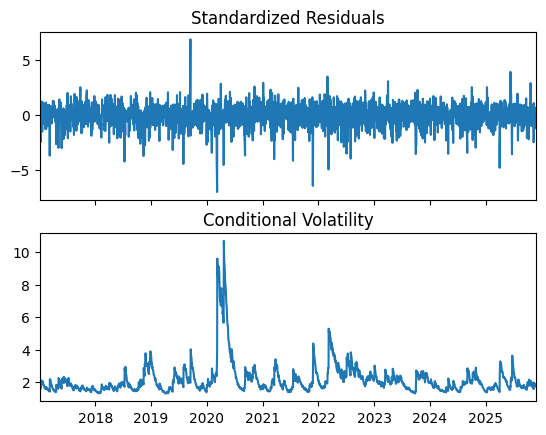

In [ ]:
# Plot GJR-GARCH model results
fig = garch_fit.plot()
plt.show()

**Standardized Residuals**

The standardized residuals appear centered around zero with no obvious trend, which indicates that the GJR-GARCH model has successfully captured the main structure in the return series. Most residuals fall within a moderate range, although occasional spikes remain. These spikes are expected in financial data and reflect the heavy-tailed nature already confirmed by the Student’s t distribution. Importantly, there is no clear clustering in the residuals, suggesting that the model has removed most of the conditional heteroskedasticity.

**Conditional Volatility**

The conditional volatility series shows clear time variation, with pronounced peaks during major market disruptions. The volatility surge in early 2020 aligns with the collapse in global oil demand during the COVID-19 shock, followed by elevated levels through the recovery period. Additional volatility increases are visible around 2021–2022, corresponding to geopolitical tensions and supply-side uncertainty. After these episodes, volatility gradually declines but remains higher than pre-2020 levels, consistent with the model’s finding of strong volatility persistence.

# VISUALIZING VOLATILITY

  1. The log-return series with a ribbon of +/- 2 standard deviations (dynamic)

  2. The absolute log-returns with the standard deviation (also dynamic)

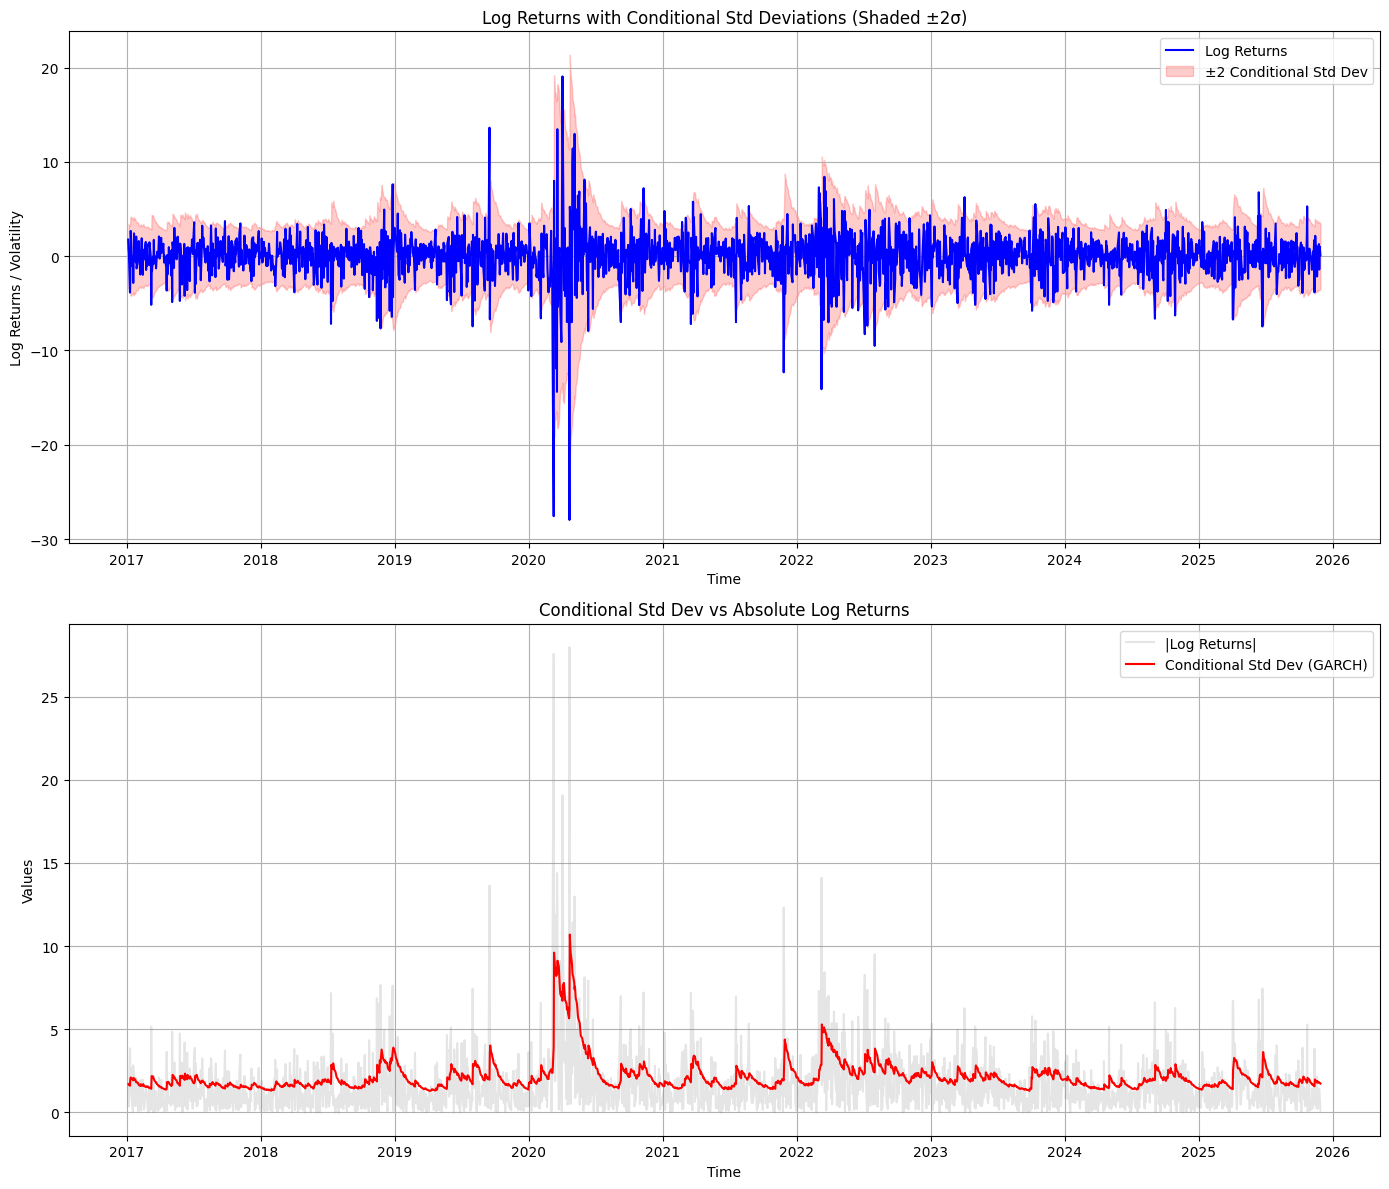

In [ ]:
# Get the conditional volatility (sigma_t) and standardized residuals
conditional_volatility = garch_fit.conditional_volatility
absolute_log_returns = np.abs(returns)

# Combined plot with two subplots stacked vertically
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Log returns with shaded ±2 conditional standard deviations
axs[0].plot(returns, label='Log Returns', color='blue')
upper_bound = 2 * conditional_volatility
lower_bound = -2 * conditional_volatility
axs[0].fill_between(brent.index, lower_bound, upper_bound, color='red', alpha=0.2, label='±2 Conditional Std Dev')
axs[0].set_title('Log Returns with Conditional Std Deviations (Shaded ±2σ)')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Log Returns / Volatility')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Conditional Std Dev vs. Absolute Log Returns
axs[1].plot(absolute_log_returns, label='|Log Returns|', color='gray', alpha=0.2)
axs[1].plot(conditional_volatility, label='Conditional Std Dev (GARCH)', color='red')
axs[1].set_title('Conditional Std Dev vs Absolute Log Returns')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Values')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and save the figure
plt.tight_layout()
plt.show()


**Log Returns with Conditional Standard Deviations (±2σ Bands)**

The first plot overlays the raw log-returns with the time-varying ±2 standard deviation bands estimated by the GJR-GARCH model. The bands expand during major volatility episodes, most notably around early 2020, capturing the extree swings during the COVID-19 oil-price collapse and rebound. Outside these periods, the bands narrow substantially, indicating calmer market conditions. Crucially, most returns fall within the shaded region, showing that the model provides a realistic estimate of the magnitude of expected fluctuations.

This behaviour confirms that the model responds appropriately to shocks: volatility increases rapidly during crises and gradually declines afterward, mirroring real market dynamics.

**Conditional Standard Deviation vs. Absolute Log Returns**

The second plot compares the conditional volatility (red line) directly with the absolute returns (grey bars). Peaks in absolute returns closely align with peaks in the conditional standard deviation. This indicates that the GJR-GARCH model successfully captures the timing and scale of volatility bursts.

The pronounced spike in 2020 again stands out, while smaller volatility waves appear in 2018–2019 and 2021–2022. After these events, volatility slowly returns to lower levels, consistent with the high persistence parameter estimated in the model.

Overall, the conditional standard deviation closely tracks realized volatility, demonstrating that the GJR-GARCH specification provides a good fit to the evolving risk profile of Brent crude oil returns.

# RESIDUAL ANALYSIS


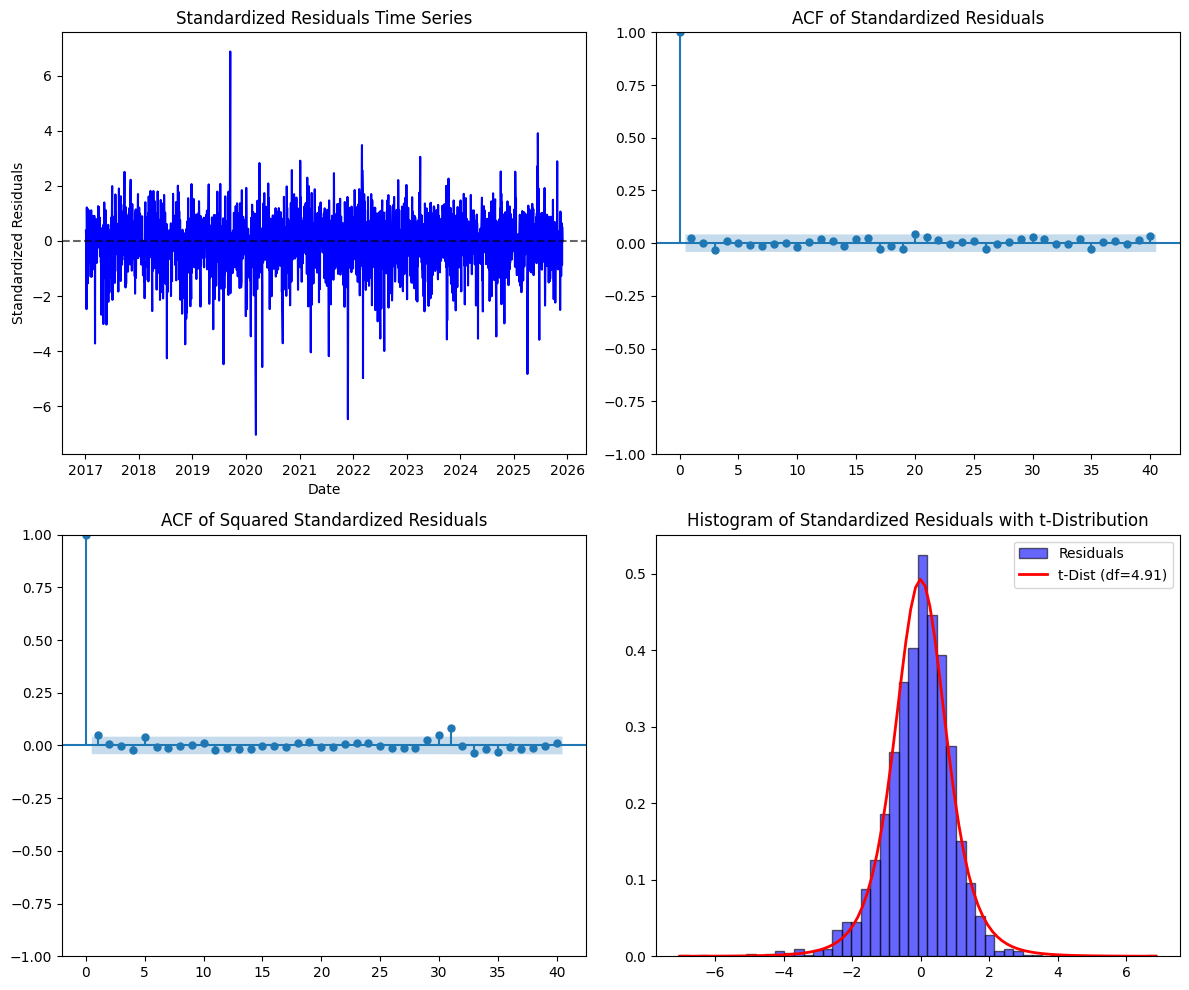

In [ ]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import t, probplot

# Compute standardized residuals
std_residuals = garch_fit.resid / garch_fit.conditional_volatility
std_residuals = std_residuals.dropna()

# Set up 2x2 residual plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Standardized residual time series
sns.lineplot(x=std_residuals.index, y=std_residuals, ax=axes[0, 0], color='blue')
axes[0, 0].set_title("Standardized Residuals Time Series")
axes[0, 0].set_ylabel("Standardized Residuals")
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.6)

# 2. ACF of standardized residuals
plot_acf(std_residuals, ax=axes[0, 1], lags=40)
axes[0, 1].set_title("ACF of Standardized Residuals")

# 3. ACF of squared standardized residuals
plot_acf(std_residuals**2, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("ACF of Squared Standardized Residuals")

# 4. QQ-plot with estimated t-distribution
df_t, loc_t, scale_t = t.fit(std_residuals)
x = np.linspace(min(std_residuals), max(std_residuals), 100)
pdf_t = t.pdf(x, df_t, loc=loc_t, scale=scale_t)

axes[1, 1].hist(std_residuals, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black', label="Residuals")
axes[1, 1].plot(x, pdf_t, color='red', lw=2, label=f't-Dist (df={df_t:.2f})')
axes[1, 1].set_title("Histogram of Standardized Residuals with t-Distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Residual Diagnostics for the GJR-GARCH Model

1. Standardized Residuals Time Series
The standardized residuals fluctuate around zero with no visible patterns or clustering. This indicates that the GJR-GARCH model has effectively removed the serial dependence and volatility structure from the return series. Occasional spikes are present but are expected in heavy-tailed financial data and are accounted for by the Student’s t distribution.

2. ACF of Standardized Residuals
The autocorrelation function shows no significant autocorrelations beyond lag 0. All autocorrelation coefficients fall within the 95% confidence bands, meaning the residuals behave like white noise. This confirms that the mean equation is adequately specified.

3. ACF of Squared Standardized Residuals
The ACF of squared residuals also displays no significant autocorrelations. This is the key diagnostic for volatility models: it demonstrates that conditional heteroskedasticity has been successfully removed. In other words, the GJR-GARCH model has captured the volatility clustering present in the original return series.

4. Histogram with Fitted t-Distribution
The standardized residuals are well approximated by the fitted Student’s t distribution (df ≈ 4.77). The t-distribution captures both the sharp central peak and the heavy tails visible in the residuals.

# RISK MODELING - VaR ESTIMATES

Compute the non-dynamic estimates of the Value-at-Risk. comparing the results of the historical VaR, with the student-t and normal distribution VaR.

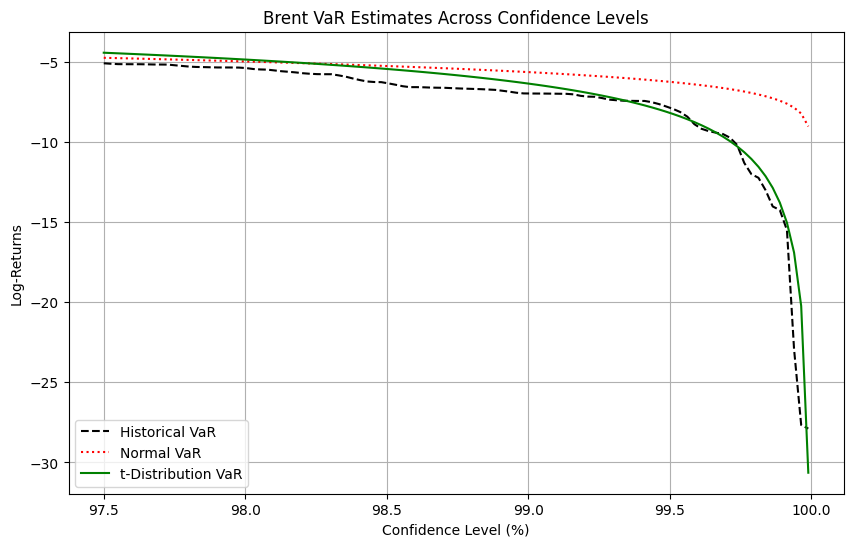

In [ ]:
# Prepare the data
returns = brent['Log_Return'].dropna()

# Confidence levels for VaR
confidence_levels = np.linspace(0.975, 0.9999, 100)

# Compute VaR for different confidence levels
VaR_hist = [np.percentile(returns, (1 - alpha) * 100) for alpha in confidence_levels]
VaR_norm = [norm.ppf(1 - alpha, loc=np.mean(returns), scale=np.std(returns)) for alpha in confidence_levels]
df_t, loc_t, scale_t = t.fit(returns)
VaR_t = [loc_t + scale_t * t.ppf(1 - alpha, df_t) for alpha in confidence_levels]

# Plot VaR estimates as a function of confidence level
plt.figure(figsize=(10, 6))
plt.plot(confidence_levels * 100, VaR_hist, label='Historical VaR', linestyle='dashed', color='black')
plt.plot(confidence_levels * 100, VaR_norm, label='Normal VaR', linestyle='dotted', color='red')
plt.plot(confidence_levels * 100, VaR_t, label='t-Distribution VaR', linestyle='solid', color='green')

plt.xlabel("Confidence Level (%)")
plt.ylabel("Log-Returns")
plt.title("Brent VaR Estimates Across Confidence Levels")
plt.legend()
plt.grid()
plt.show()

Normal VaR underestimates risk, especially beyond 99%.

T-distribution VaR aligns closely with historical risk, providing a substantially more realistic measure of extreme downside risk.

This supports the earlier diagnostic findings that Brent crude returns are heavy-tailed, and that a t-GJR-GARCH model provides a more accurate framework for forecasting volatility and quantifying risk.

# RISK MANAGEMENT - EXPECTED SHORTFALL

Given the VaR compute the Expected shorfall

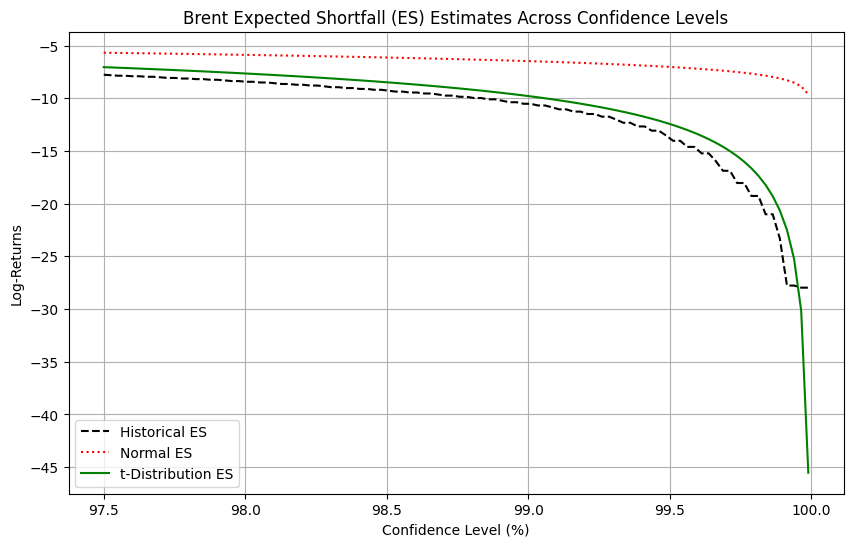

In [ ]:
# Compute Expected Shortfall (ES) using the proper formulas
mean_return, std_return = returns.mean(), returns.std()
phi_norm = norm.pdf(norm.ppf(confidence_levels))
ES_norm = mean_return - std_return * (phi_norm / (1 - confidence_levels))

# Compute t-Distribution Expected Shortfall
t_alpha = t.ppf(confidence_levels, df_t)
t_pdf_alpha = t.pdf(t_alpha, df_t)
ES_t = loc_t - scale_t * (t_pdf_alpha / (1 - confidence_levels)) * (df_t + t_alpha**2) / (df_t - 1)

# Compute Historical Expected Shortfall (ES) directly from data
ES_hist = [returns[returns <= VaR_hist[i]].mean() for i in range(len(confidence_levels))]

# Plot Expected Shortfall (ES) estimates as a function of confidence level
plt.figure(figsize=(10, 6))
plt.plot(confidence_levels * 100, ES_hist, label='Historical ES', linestyle='dashed', color='black')
plt.plot(confidence_levels * 100, ES_norm, label='Normal ES', linestyle='dotted', color='red')
plt.plot(confidence_levels * 100, ES_t, label='t-Distribution ES', linestyle='solid', color='green')
plt.grid()
plt.xlabel("Confidence Level (%)")
plt.ylabel("Log-Returns")
plt.title("Brent Expected Shortfall (ES) Estimates Across Confidence Levels")
plt.legend()

The normal distribution ES consistently produces the least severe risk estimate across all confidence levels. Even at the extreme tail (near 99.9%), the normal ES curve remains far above the historical and t-based estimates. This reflects the normal distribution’s inability to account for the large downside shocks characteristic of oil markets. The normal model substantially underestimates tail risk.

Historical ES provides the empirical benchmark. It becomes much more severe at higher confidence levels, reflecting the significant drawdowns observed in events such as the 2020 market collapse. The historical ES curve steepens noticeably near 99.5%–100%, showing that real-world tail losses escalate rapidly.

The t-distribution ES closely tracks the historical ES across all confidence levels and converges very tightly near the extreme tail. This indicates that the t-innovation GJR-GARCH model successfully reproduces the empirical severity of large losses. The heavy tails of the t-distribution allow it to generate realistic estimates of extreme downside risk, which the normal model cannot.

# DYNAMIC RISK MODELING

Compute dynamic VaR estimates, for the historical Brent close price data using our GJR-GARCH model.

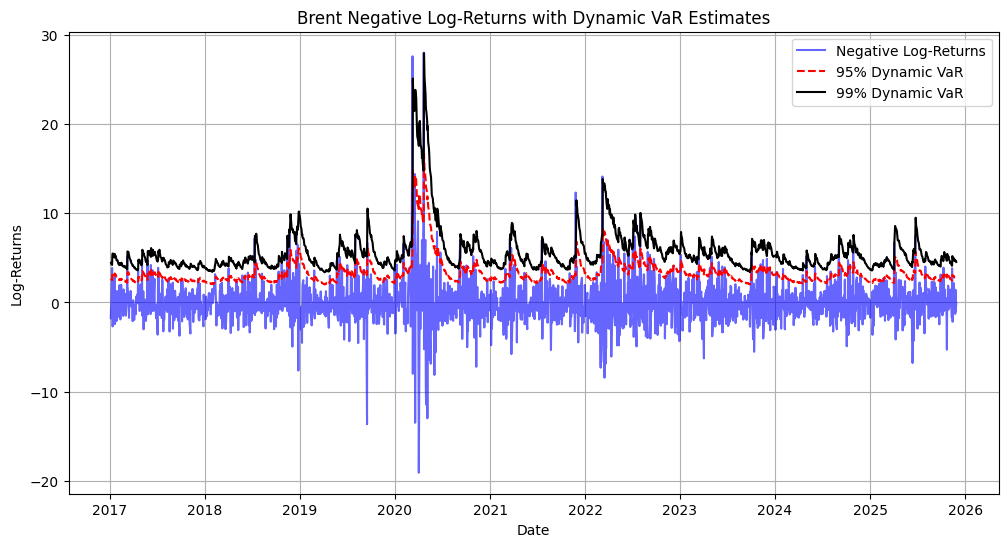

In [ ]:
# Extract conditional volatility and standardized residuals
std_residuals = garch_fit.resid / garch_fit.conditional_volatility
std_residuals = std_residuals.dropna()
cond_volatility = garch_fit.conditional_volatility.dropna()

# Fit t-distribution to standardized residuals
df_t, loc_t, scale_t = t.fit(std_residuals)

# Compute dynamic VaR at 95% and 99%
VaR_95 = -scale_t * t.ppf(0.05, df_t) * cond_volatility
VaR_99 = -scale_t * t.ppf(0.01, df_t) * cond_volatility

# Plot time series of negative log-returns with dynamic VaR
plt.figure(figsize=(12, 6))
plt.plot(-returns, label="Negative Log-Returns", color='blue', alpha=0.6)
plt.plot(VaR_95, label="95% Dynamic VaR", linestyle='dashed', color='red')
plt.plot(VaR_99, label="99% Dynamic VaR", linestyle='solid', color='black')

plt.xlabel("Date")
plt.ylabel("Log-Returns")
plt.title("Brent Negative Log-Returns with Dynamic VaR Estimates")
plt.legend()
plt.grid()
plt.show()

The plot shows the dynamic VaR at each time point. The red and black lines show VaR at a 95% and 99% (respectively) confidence level. They represent model-estimated thresholds for extreme losses, updated daily based on your GJR-GARCH conditional volatility forecasts and the Student-t distribution.

Volatility and VaR rise sharply in early 2020 and 2022.
- Both VaR lines spike dramatically during the COVID-19 market collapse and the 2022 Russia-Ukraine war shocks.
- This indicates extreme risk and severe widening of the loss distribution.

After the major COVID-19 and Russia-Ukraine war shocks, the VaR thresholds remain elevated for a while, reflecting persistent volatility

There are a few moments where the blue bars dip below the 95% and 99% lines, which means that real-world extreme events occasionally exceed even the 99% VaR.